<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/Notebook_1_Click/NoteBook02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


In [6]:
from google.colab import files

uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System.csv


In [7]:
df = pd.read_csv('Conditional_Base_Monitoring in Marine_System.csv')

df.columns = df.columns.str.strip()

df = df.apply(pd.to_numeric, errors='coerce')

df = df.dropna()

df = df.drop_duplicates()

print('Dataset loaded and cleaned')
print('Shape:', df.shape)

Dataset loaded and cleaned
Shape: (11936, 18)


In [8]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nStatistical Summary:')
df.describe()

Shape: (11936, 18)

Data Types:
Lever position                                            float64
Ship speed (v)                                            float64
Gas Turbine (GT) shaft torque (GTT) [kN m]                float64
GT rate of revolutions (GTn) [rpm]                        float64
Gas Generator rate of revolutions (GGn) [rpm]             float64
Starboard Propeller Torque (Ts) [kN]                      float64
Port Propeller Torque (Tp) [kN]                           float64
Hight Pressure (HP) Turbine exit temperature (T48) [C]    float64
GT Compressor inlet air temperature (T1) [C]              float64
GT Compressor outlet air temperature (T2) [C]             float64
HP Turbine exit pressure (P48) [bar]                      float64
GT Compressor inlet air pressure (P1) [bar]               float64
GT Compressor outlet air pressure (P2) [bar]              float64
GT exhaust gas pressure (Pexh) [bar]                      float64
Turbine Injecton Control (TIC) [%]          

,Lever position,Ship speed (v),Gas Turbine (GT) shaft torque (GTT) [kN m],GT rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],Hight Pressure (HP) Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],GT exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Compressor decay state coefficient,GT Turbine decay state coefficient
count,11936.000000,11936.000000,11936.000000,11936.000000,11936.000000,11936.000000,11936.000000,11936.000000,11936.0,11936.000000,11936.000000,1.193600e+04,11936.000000,11936.000000,11936.000000,11936.000000,11936.000000,11936.000000
mean,5.166580,14.999749,27245.979402,2136.222165,8200.937721,227.321895,227.321895,735.488909,288.0,646.212572,2.352882,9.980000e-01,12.296755,1.029473,33.639351,0.662402,0.974996,0.987498
std,2.626184,7.745691,22147.113470,774.040215,1091.233780,200.482350,200.482350,173.667325,0.0,72.670396,1.084701,2.533635e-13,5.337096,0.010390,25.839674,0.507098,0.014723,0.007501
min,1.138000,3.000000,253.547000,1307.675000,6589.002000,5.304000,5.304000,442.364000,288.0,540.442000,1.093000,9.980000e-01,5.828000,1.019000,0.000000,0.068000,0.950000,0.975000
25%,3.144000,9.000000,8375.885250,1386.758000,7058.376000,60.317000,60.317000,589.874250,288.0,578.098750,1.389000,9.980000e-01,7.447750,1.020000,13.692500,0.246000,0.962000,0.981000
50%,5.140000,15.000000,21630.659000,1924.326000,8482.081500,175.268000,175.268000,706.038000,288.0,637.141500,2.083000,9.980000e-01,11.092000,1.026000,25.276500,0.496000,0.975000,0.987000
75%,7.148000,21.000000,39001.426250,2678.079000,9132.598000,332.364250,332.364250,834.016750,288.0,693.917500,2.981000,9.980000e-01,15.658000,1.036000,44.551500,0.882000,0.988000,0.994000
max,9.300000,27.000000,72784.872000,3560.741000,9797.103000,645.249000,645.249000,1115.797000,288.0,789.094000,4.560000,9.980000e-01,23.140000,1.052000,92.556000,1.832000,1.000000,1.000000


In [9]:
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values[missing_values > 0])
print('\nTotal missing:', df.isnull().sum().sum())

Missing values per column:
Series([], dtype: int64)

Total missing: 0


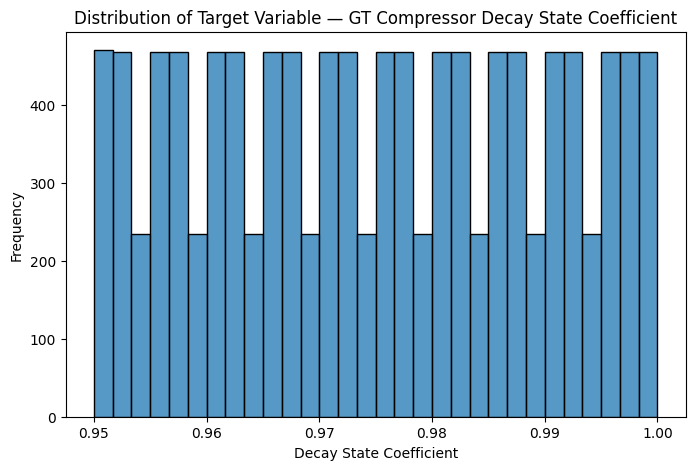

In [10]:
target_column = 'GT Compressor decay state coefficient'

plt.figure(figsize=(8, 5))
sns.histplot(df[target_column], bins=30)
plt.title('Distribution of Target Variable — GT Compressor Decay State Coefficient')
plt.xlabel('Decay State Coefficient')
plt.ylabel('Frequency')
plt.show()

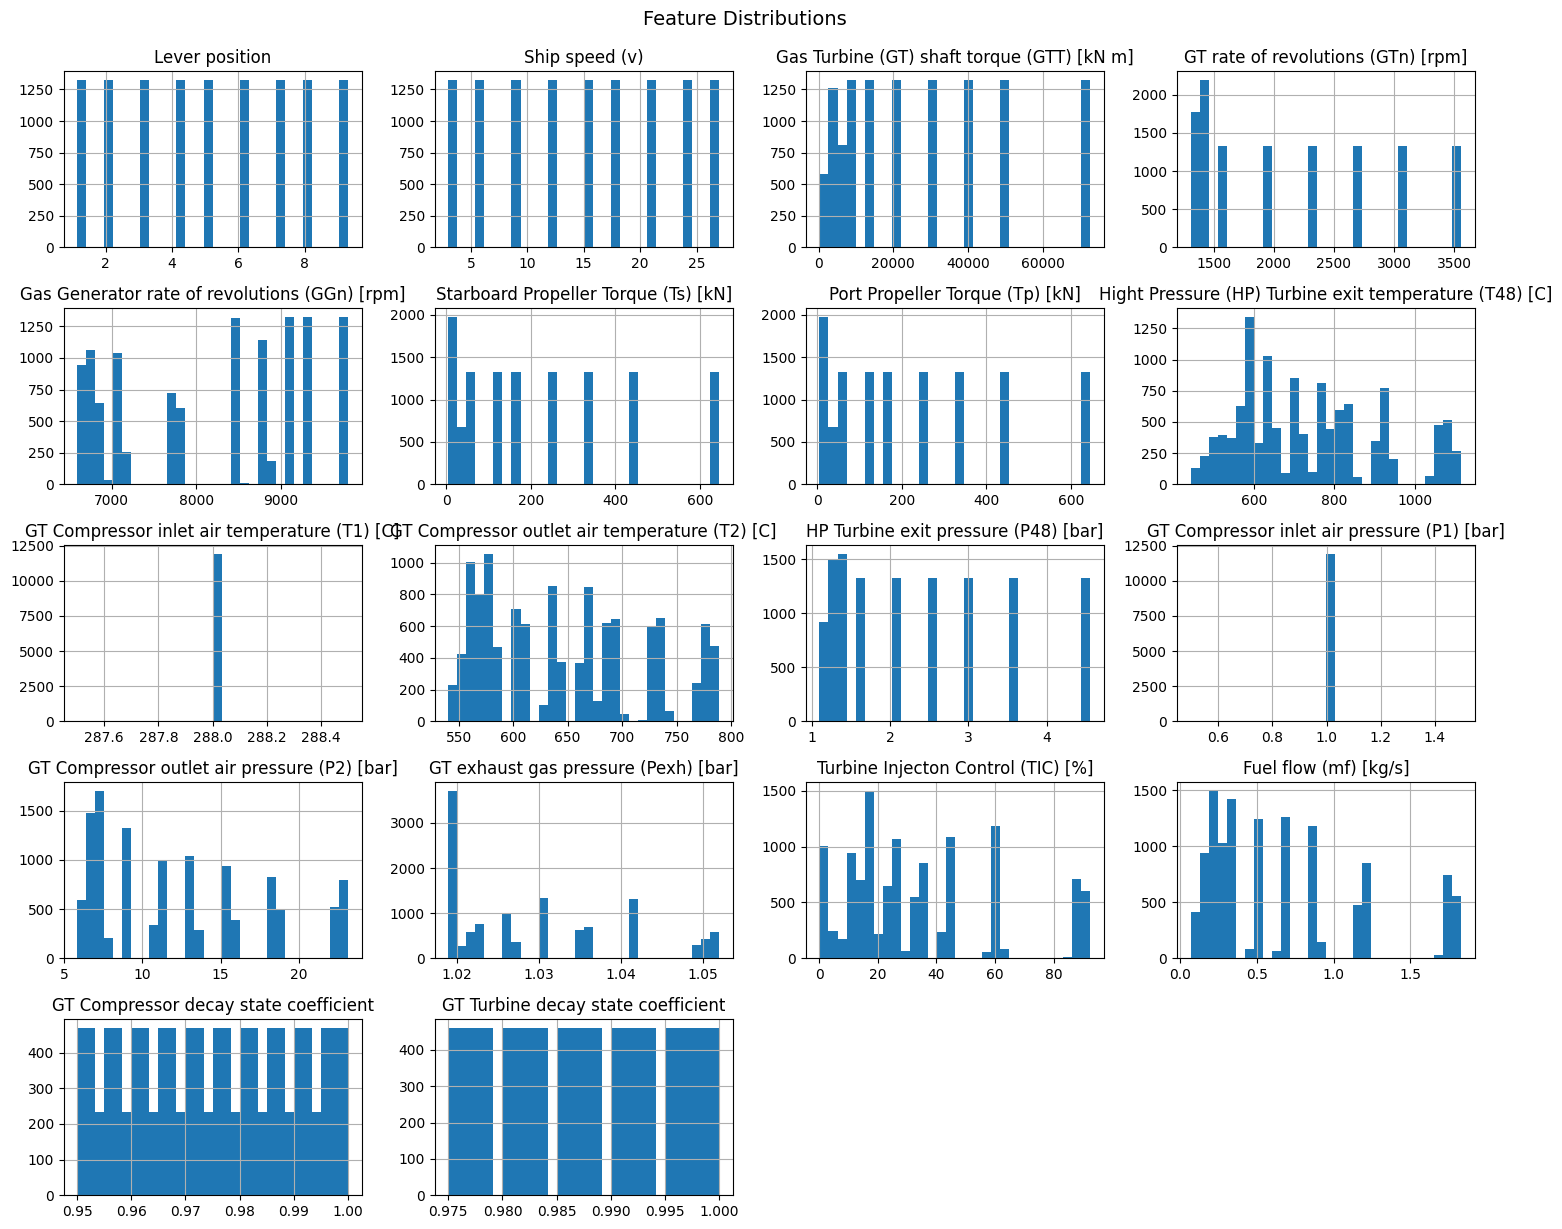

In [11]:
df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.suptitle('Feature Distributions', y=1.02, fontsize=14)
plt.show()

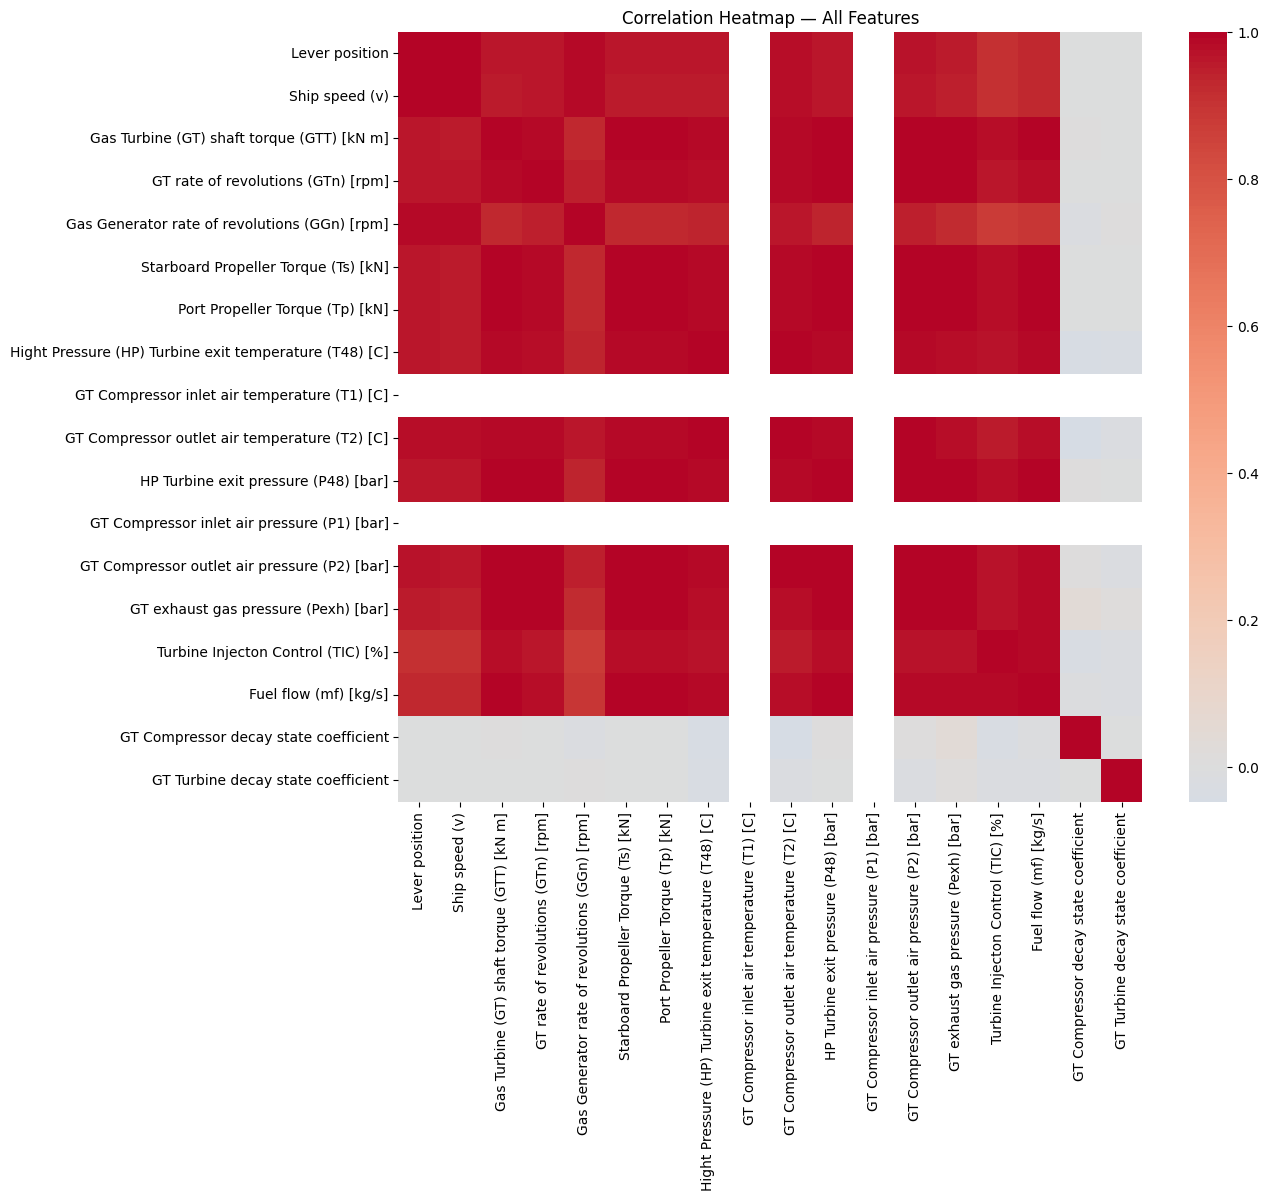

In [12]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False
)
plt.title('Correlation Heatmap — All Features')
plt.show()

In [13]:
target_corr = df.corr()[target_column].sort_values(ascending=False)

print('Correlation with target variable:')
print(target_corr)

Correlation with target variable:
GT Compressor decay state coefficient                     1.000000
GT exhaust gas pressure (Pexh) [bar]                      0.035426
GT Compressor outlet air pressure (P2) [bar]              0.008443
HP Turbine exit pressure (P48) [bar]                      0.008293
Gas Turbine (GT) shaft torque (GTT) [kN m]                0.003094
GT rate of revolutions (GTn) [rpm]                        0.001517
Port Propeller Torque (Tp) [kN]                           0.000871
Starboard Propeller Torque (Ts) [kN]                      0.000871
GT Turbine decay state coefficient                        0.000474
Lever position                                            0.000056
Ship speed (v)                                            0.000055
Fuel flow (mf) [kg/s]                                    -0.013539
Gas Generator rate of revolutions (GGn) [rpm]            -0.018818
Turbine Injecton Control (TIC) [%]                       -0.031903
Hight Pressure (HP) Turbine 

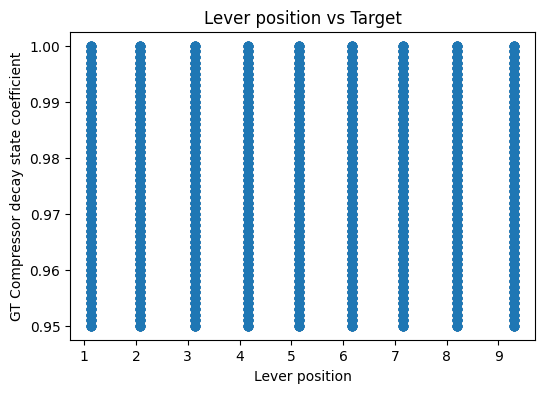

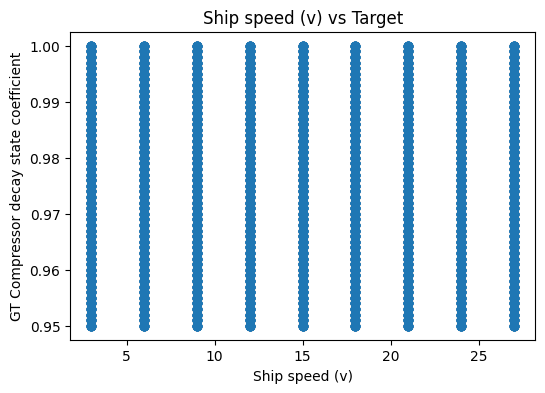

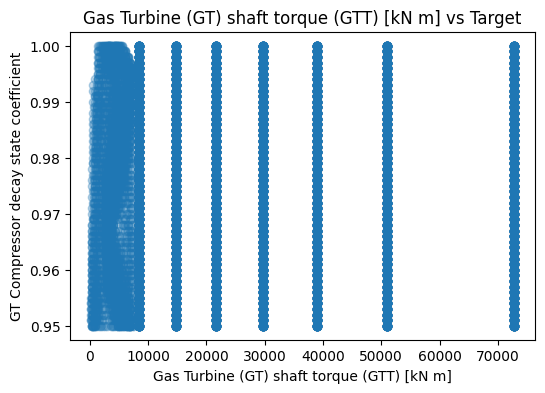

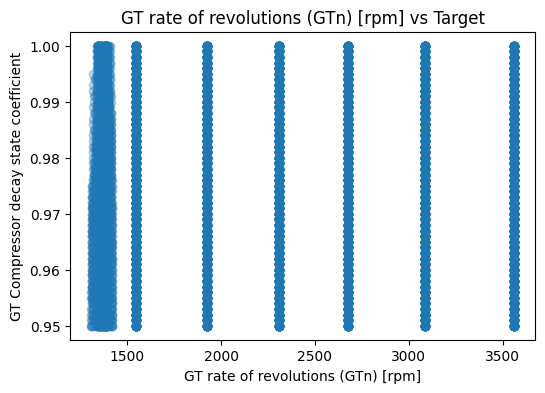

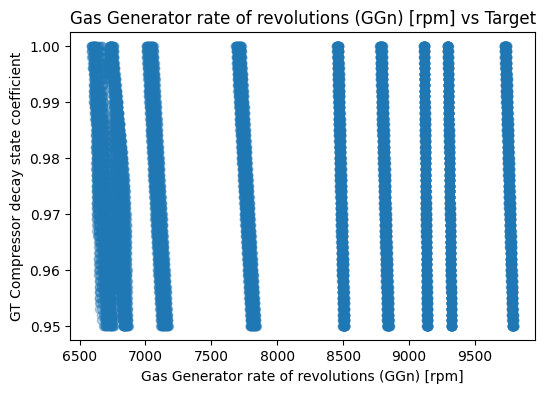

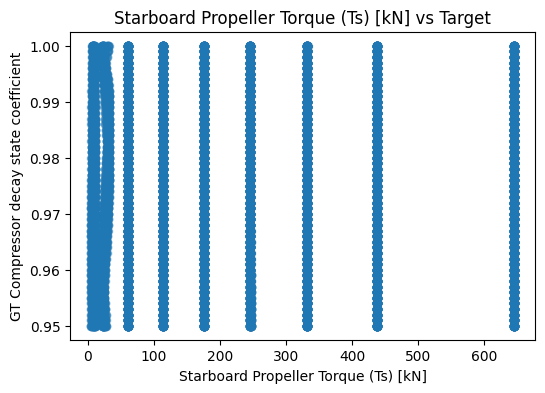

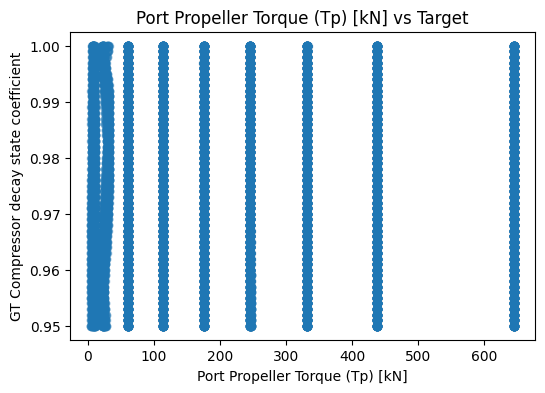

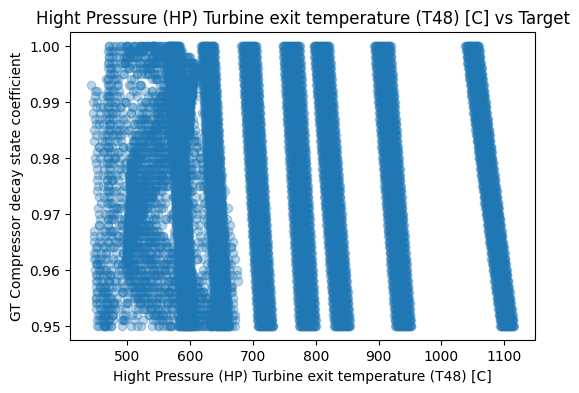

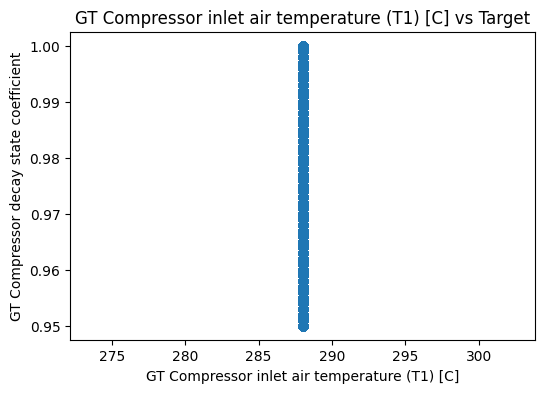

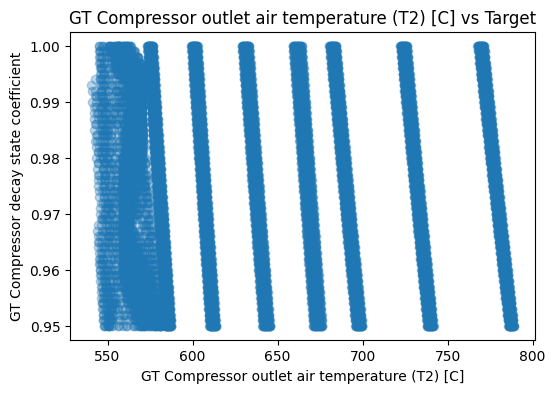

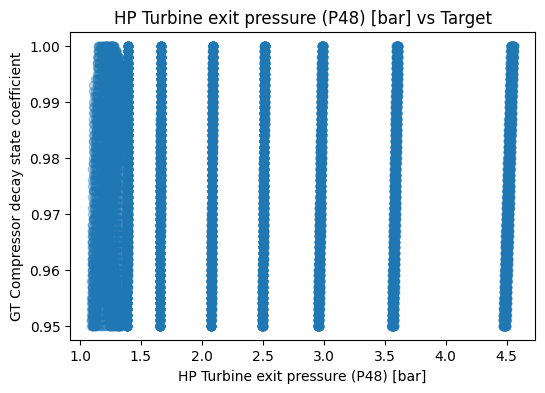

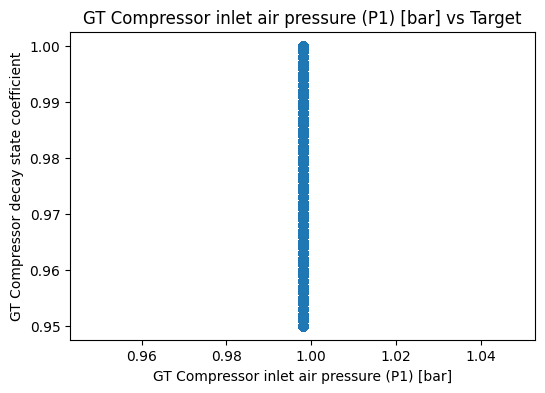

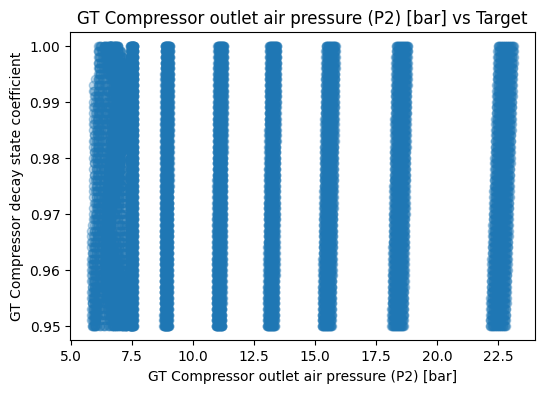

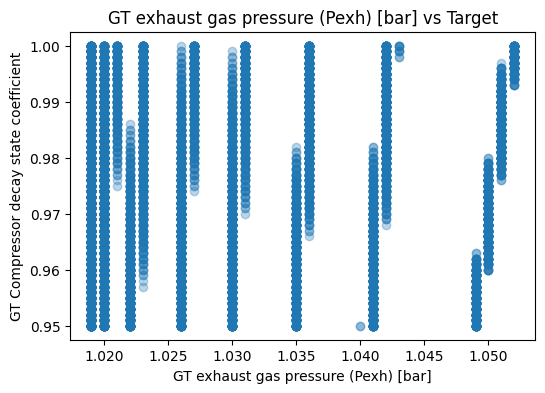

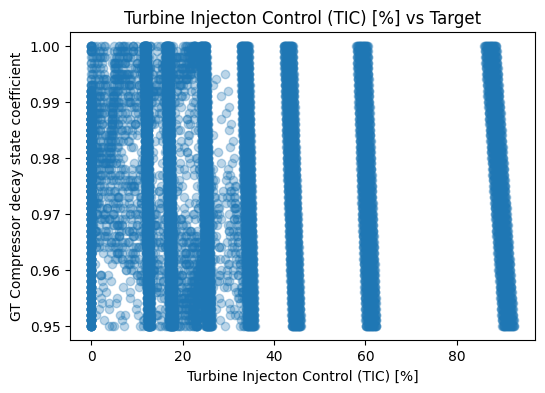

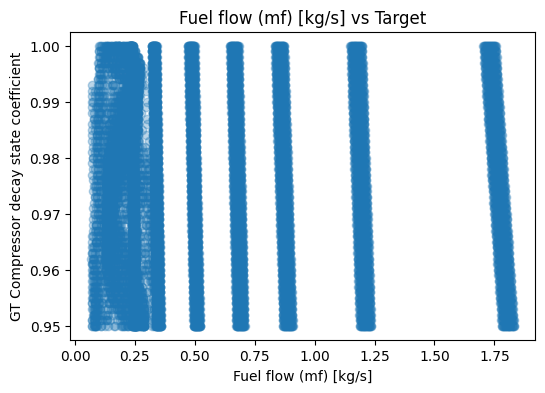

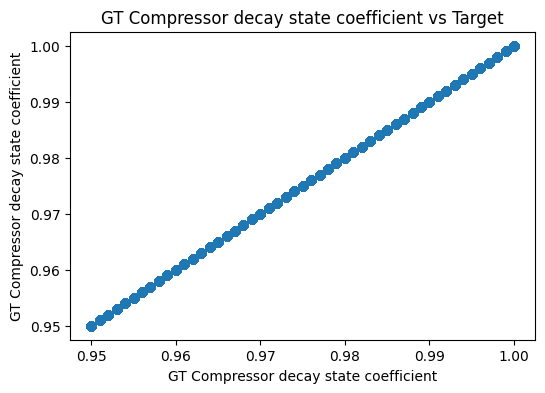

In [14]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df[target_column], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel(target_column)
    plt.title(f'{col} vs Target')
    plt.show()

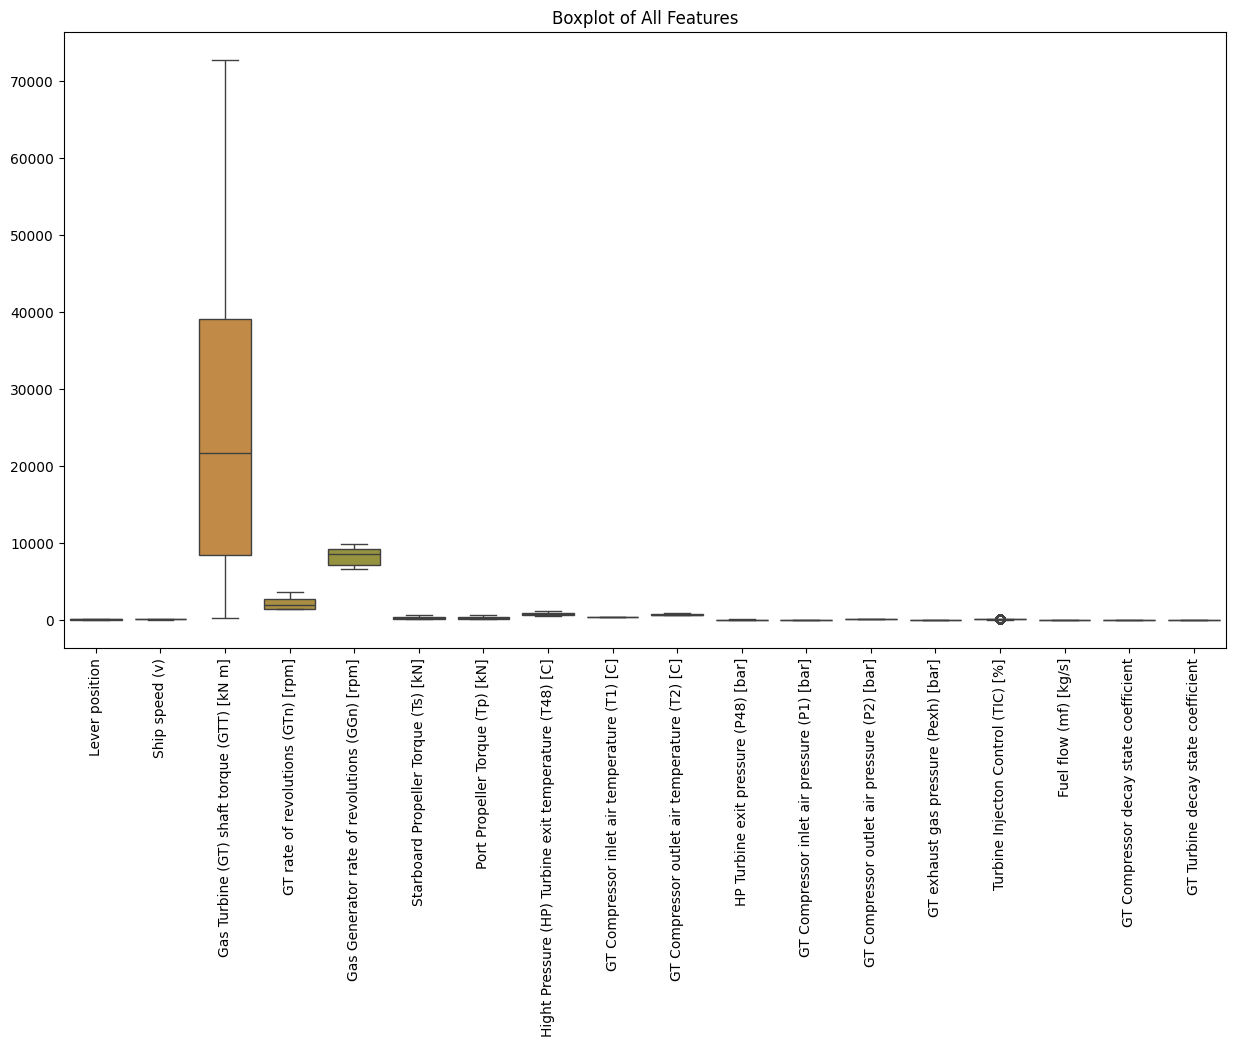

In [15]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Boxplot of All Features')
plt.show()